In [1]:
from scipy import sparse
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import os
os.environ["MKL_THREADING_LAYER"] = "GNU"

In [2]:
X = sparse.load_npz("../datasets/clusterization/train.npz")

In [3]:
print(f"Размер: {X.shape}")
M, N = X.shape
print(X[:1, :].toarray().max(), X[:1, :].toarray().min(), X[:1, :].toarray().mean())

Размер: (21000, 3049)
7598.588105474598 -13.815510557964274 2.568935238165224


In [4]:
all_lens = []
for i in range(M):
    row = X[i].data
    all_lens.append(len(row.tolist()))
arr = np.array(all_lens)
values, counts = np.unique(arr, return_counts=True) 
print(f"Мода по размерности: {values[np.argmax(counts)]}")

Мода по размерности: 554


### <div align="center">PCA</div>

In [5]:
def plot_the_PCA_interval(pca_obj, start, stop, step, show_ratios=False, print_cum=False):
    interval = np.arange(start, stop, step)

    explained_variance_ratio = pca_obj.explained_variance_ratio_[interval]
    explained_variance_ratio_reduced = explained_variance_ratio.copy()[1::]
    rations = np.insert(explained_variance_ratio[:-1:]/explained_variance_ratio_reduced, 0, 0)
    cumulative = np.cumsum(pca_obj.explained_variance_ratio_)[interval]
    components = np.arange(0, len(explained_variance_ratio))*step + start

    plt.figure(figsize=(8, 5))
    plt.bar(components, explained_variance_ratio, alpha=0.7, label='Individual')
    plt.plot(components, cumulative, 'ro-', label='Cumulative')
    plt.xlabel('Number of Components')
    plt.ylabel('Explained Variance Ratio')
    plt.xticks(components)
    plt.legend()
    plt.grid(True)
    plt.show()

    if show_ratios or print_cum:
        for comp, cum, ratio in zip(components, cumulative, rations):
            string = f"Компонент {comp}: "
            if show_ratios: string += f"cum={cum:.4f}; "
            if print_cum: string += f"ratio={ratio:.4f}; "
            print(string)

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
scaler = StandardScaler(with_mean=False)
X = scaler.fit_transform(X)

In [ ]:
# pca = PCA()
# pca.fit(X)

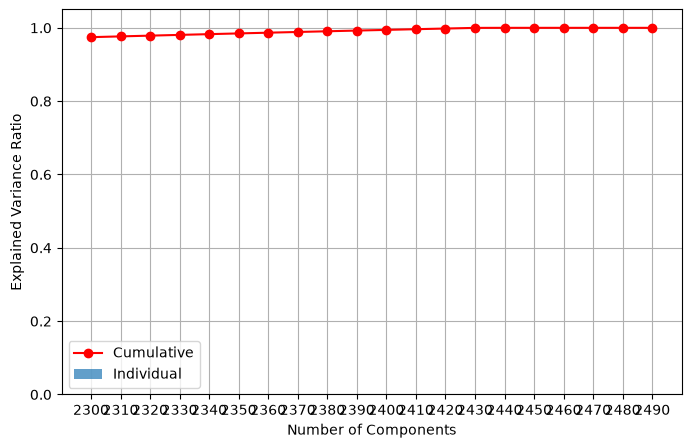

Компонент 2300: cum=0.9746; ratio=0.0000; 
Компонент 2310: cum=0.9766; ratio=1.0106; 
Компонент 2320: cum=0.9787; ratio=1.0101; 
Компонент 2330: cum=0.9807; ratio=1.0094; 
Компонент 2340: cum=0.9828; ratio=1.0105; 
Компонент 2350: cum=0.9848; ratio=1.0112; 
Компонент 2360: cum=0.9867; ratio=1.0131; 
Компонент 2370: cum=0.9887; ratio=1.0097; 
Компонент 2380: cum=0.9906; ratio=1.0129; 
Компонент 2390: cum=0.9925; ratio=1.0129; 
Компонент 2400: cum=0.9944; ratio=1.0145; 
Компонент 2410: cum=0.9963; ratio=1.0169; 
Компонент 2420: cum=0.9981; ratio=1.0211; 
Компонент 2430: cum=0.9998; ratio=1.0311; 
Компонент 2440: cum=1.0000; ratio=27345113310679013789207101440.0000; 
Компонент 2450: cum=1.0000; ratio=1.3191; 
Компонент 2460: cum=1.0000; ratio=1.2498; 
Компонент 2470: cum=1.0000; ratio=1.2230; 
Компонент 2480: cum=1.0000; ratio=1.2457; 
Компонент 2490: cum=1.0000; ratio=1.1345; 


In [ ]:
# # на 2450 объяснена вся дисперсия (с точностью до 1e-8)
# start, stop, step = 2300, 2500, 10
# plot_the_PCA_interval(pca, start, stop, step, show_ratios=True, print_cum=True)

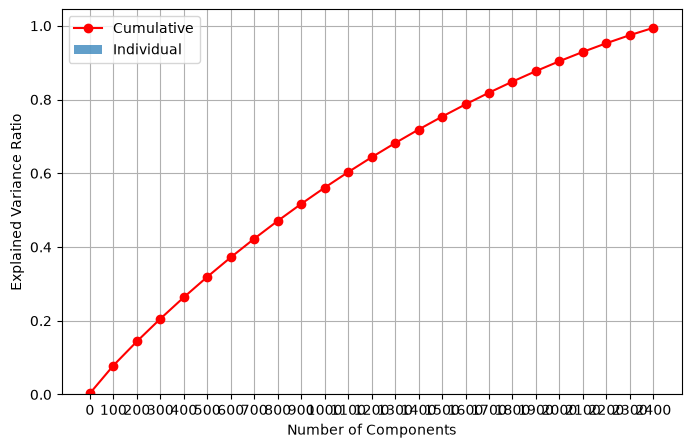

Компонент 0: cum=0.0032; ratio=0.0000; 
Компонент 100: cum=0.0786; ratio=4.6719; 
Компонент 200: cum=0.1438; ratio=1.0676; 
Компонент 300: cum=0.2053; ratio=1.0576; 
Компонент 400: cum=0.2636; ratio=1.0526; 
Компонент 500: cum=0.3190; ratio=1.0495; 
Компонент 600: cum=0.3720; ratio=1.0469; 
Компонент 700: cum=0.4225; ratio=1.0480; 
Компонент 800: cum=0.4707; ratio=1.0456; 
Компонент 900: cum=0.5169; ratio=1.0457; 
Компонент 1000: cum=0.5610; ratio=1.0470; 
Компонент 1100: cum=0.6031; ratio=1.0459; 
Компонент 1200: cum=0.6434; ratio=1.0466; 
Компонент 1300: cum=0.6818; ratio=1.0478; 
Компонент 1400: cum=0.7185; ratio=1.0483; 
Компонент 1500: cum=0.7535; ratio=1.0487; 
Компонент 1600: cum=0.7869; ratio=1.0513; 
Компонент 1700: cum=0.8186; ratio=1.0535; 
Компонент 1800: cum=0.8486; ratio=1.0546; 
Компонент 1900: cum=0.8771; ratio=1.0580; 
Компонент 2000: cum=0.9039; ratio=1.0618; 
Компонент 2100: cum=0.9292; ratio=1.0661; 
Компонент 2200: cum=0.9527; ratio=1.0750; 
Компонент 2300: cum=0.9

In [ ]:
# start, stop, step = 0, 2450, 100
# plot_the_PCA_interval(pca, start, stop, step, show_ratios=True, print_cum=True)

### Conclusion (PCA):
Можно просто урезать размерность до 2450 компонент не теряя дисперсию. У нас уже есть натренированный PCA, попробуем его применить перед t-sne и umap

In [11]:
pca_new = PCA(n_components=2450)
X_embedded_pca = pca_new.fit_transform(X)

### <div align="center">t-SNE</div>

In [9]:
def plot_3D(X, y=None, title=None, size=2):    
    fig = px.scatter_3d(
        x=X[:, 0], 
        y=X[:, 1], 
        z=X[:, 2] if X.shape[1] >= 3 else np.zeros(X.shape[0]),
        color=y,
        title=title,
        size=[size for i in range(X.shape[0])]
    )
    fig.write_html(f"temp_3d_plot_{title}.html")
    fig.show()


In [10]:
from sklearn.manifold import TSNE

In [ ]:
# # попробуем применить к сырым данным
# X_embedded_tsne = TSNE(n_components=3, 
#                   init='random').fit_transform(X[:1000])

In [ ]:
# plot_3D(X_embedded_tsne, title="t-SNE")

In [ ]:
# X_embedded_pca_tsne = TSNE(n_components=3, 
#                   init='random').fit_transform(X_embedded_pca)

PCA ready


In [ ]:
# plot_3D(X_embedded_pca_tsne, title="PCA + t-SNE")

### <div align=center> UMAP </div>

In [12]:
import umap as up

In [ ]:
# umap = up.UMAP(n_components=2, n_neighbors=2)
# X_embedded_pca_umap = umap.fit_transform(X_embedded_pca)
# plot_3D(X_embedded_pca_umap, title="PCA+UMAP_n2")

c:\Users\user_1\miniforge3\envs\ipynb_VK\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:325: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


In [18]:
umap = up.UMAP(n_components=3, n_neighbors=2)
X_embedded_pca_umap = umap.fit_transform(X_embedded_pca)
plot_3D(X_embedded_pca_umap, title="PCA+UMAP_n2_2")

c:\Users\user_1\miniforge3\envs\ipynb_VK\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:325: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


### <div align="center">Clusterization</div>

In [14]:
import hdbscan
import time
import seaborn as sns
plot_kwds = {'alpha' : 0.25, 's' : 80, 'linewidths':0}

In [ ]:
def plot_clusters(data, algorithm, args, kwds={}):
    start_time = time.time()
    labels = algorithm(*args, **kwds).fit_predict(data)
    end_time = time.time()
    palette = sns.color_palette('deep', np.unique(labels).max() + 1)
    colors = [palette[x] if x >= 0 else (0.0, 0.0, 0.0) for x in labels]
    plt.scatter(data.T[0], data.T[1], c=colors, **plot_kwds)
    frame = plt.gca()
    frame.axes.get_xaxis().set_visible(False)
    frame.axes.get_yaxis().set_visible(False)
    plt.title('Clusters found by {}'.format(str(algorithm.__name__)), fontsize=24)
    plt.text(-0.5, 0.7, 'Clustering took {:.2f} s'.format(end_time - start_time), fontsize=14)

In [16]:
plot_clusters(X_embedded_pca_umap, hdbscan.HDBSCAN, kwds={"min_clustersize": 10})

TypeError: hdbscan.hdbscan_.HDBSCAN() argument after * must be an iterable, not NoneType